El modelo SIR (básico) es un modelo epidemiológico que simula el desarrollo de una enfermedad sobre una población:
[Sistema de ED del modelo SIR](\resources\ED_SIR.png)

Donde S es la población sana, I la población infectada, R la población recuperada y N la población total. Beta (transmisión) y gamma (recuperación) son constantes de ajuste que definen la "agresividad" de la enfermedad.


Preparamos las condiciones inciales y las características del sistema a simular.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#Constantes del modelo SIR
beta = 0.9 #Tasa de infección
gamma = 0.1 #Tasa de recuperación
N = 7e9 #Población total
S0 = N - 1 #Número inicial de susceptibles
I0 = 1 #Número inicial de infectados
R0 = 0 #Número inicial de recuperados
dias = 365 #Tiempo de simulación


Calculamos el cambio en el tiempo de cada sección poblacional.

In [2]:
#Sistema de ED del modelo SIR
def SIR(S, I, R, beta, gamma, N):
    dS_dt = -(beta * S * I)/N
    dI_dt = (beta * S * I)/N - gamma * I
    dR_dt = gamma * I
    return dS_dt, dI_dt, dR_dt

Simulamos el sistema durante el tiempo designado.

In [3]:
#Simulación del sistema de ED SIR
def simu_SIR(S0, I0, R0, beta, gamma, N, dias):
    S = np.zeros(dias)
    I = np.zeros(dias)
    R = np.zeros(dias)
    
    S[0] = S0
    I[0] = I0
    R[0] = R0
    
    for t in range(1, dias):
        dS_dt, dI_dt, dR_dt = SIR(S[t-1], I[t-1], R[t-1], beta, gamma, N)
        S[t] = S[t-1] + dS_dt
        I[t] = I[t-1] + dI_dt
        R[t] = R[t-1] + dR_dt
        
    return S, I, R

Finalmente obtenemos S, I y R como una evolución temporal continua bajo el sistema de ED del modelo SIR.

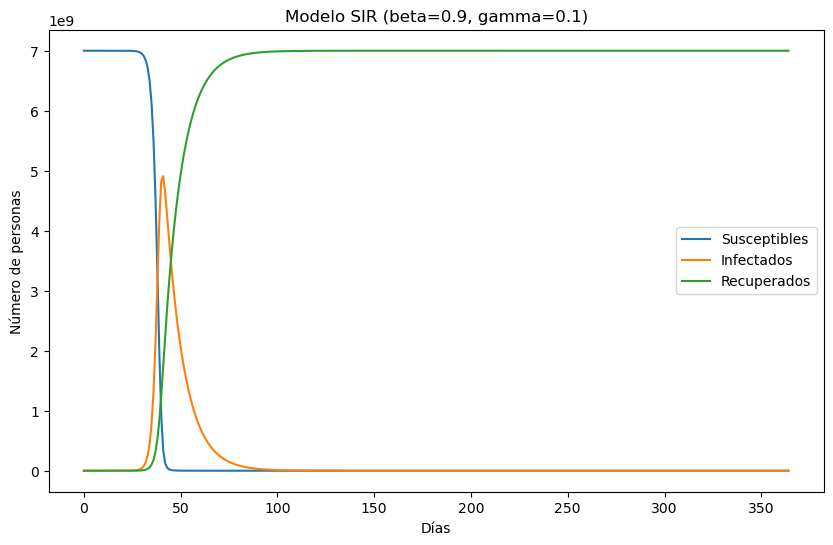

In [ ]:
#Simulación
S, I, R = simu_SIR(S0, I0, R0, beta, gamma, N, dias)
#Gráfica de resultados
plt.figure(figsize=(10,6))
plt.plot(S, label='Susceptibles')
plt.plot(I, label='Infectados')
plt.plot(R, label='Recuperados')
plt.xlabel('Días')
plt.ylabel('Número de personas')
plt.title('Modelo SIR \n(beta={}, gamma={})'.format(beta, gamma))
plt.legend()
plt.show()

Catalogaremos los modelados en base a beta y gamma de la forma que se muestra en las imágenes generadas.

Referencias:

-[Articulo extendido en el modelo SIR](https://www.scielosp.org/article/rcsp/2020.v46suppl1/e2597/es/)

-[Epidemia zomibie modelada con SIR](https://blogs.cornell.edu/info2040/2019/12/04/modeling-a-zombie-epidemic-using-sir/)

-[Diversos escenarios modelados con SIR](https://rpubs.com/AxRodro/SIR_2)